In this notebook, we use fMRI data of 9 participants who performed a rhyming judgment task. Each participant's recordings contain 9 variables: one task regressor (Input I) and 8 brain regions (LOCC, ROCC, LIPL, RIPL, LACC, RACC, LIFG, RIFG). The preprocessed dataset can be found at: https://github.com/cabal-cmu/Feedback-Discovery

We then apply one of our algorithms (PairwiseLiMVAM, DirectLiMVAM, or ICA-LiMVAM) to recover a causal graph between the 9 variables.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from limvam.ica_limvam import ica_limvam
from limvam.pairwise_limvam import pairwise_limvam
from limvam.direct_limvam import direct_limvam

# Load data

In [41]:
# parameters
df_numbers = ["001", "004", "005", "009", "010", "013", "014", "016", "017"]
random_state = 42
keep_n_entries = 10
algo = "pairwise_limvam"
standardize = False
save = True

In [42]:
# read data
X = []
for i in df_numbers:
    filename = f"data/sub{i}.cent-table.9.dat.txt"
    df = pd.read_csv(filename, sep="\t")
    data = df.to_numpy().T
    # normalize
    data -= np.mean(data, axis=1)[:, None]
    data /= np.std(data, axis=1)[:, None]
    X.append(data)
X = np.array(X)
cols = df.columns.values.tolist()

print(f"Dataset shape : {X.shape}")

Dataset shape : (9, 9, 160)


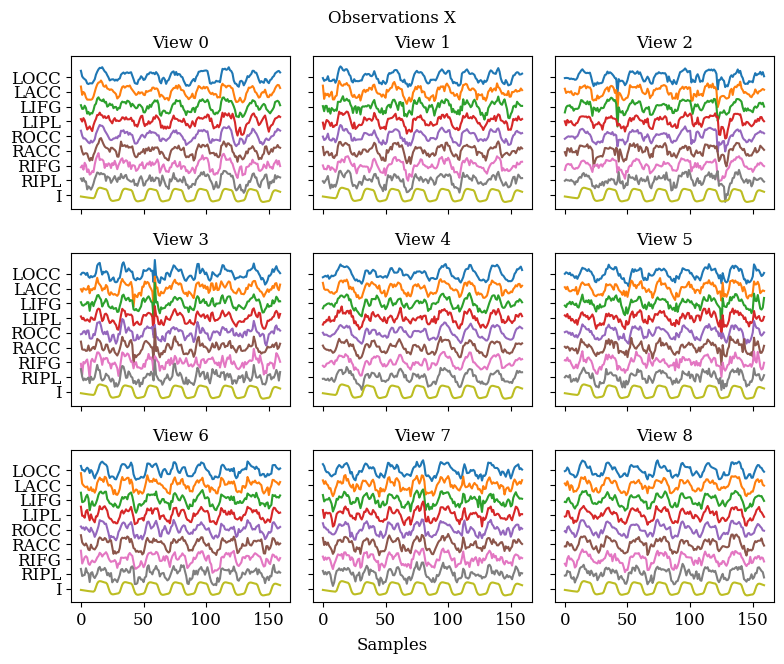

In [43]:
# matplotlib style
fontsize = 12
rc = {
    "font.size": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "font.family": "serif",
}
plt.rcParams.update(rc)

# plot X
fig, axes = plt.subplots(3, 3, figsize=(8, 7), sharex=True, sharey=True)
height = 3
for i in range(X.shape[0]):
    ax = axes[i // 3, i % 3]
    for j in range(X.shape[1]):
        ax.plot(X[i, j] - height * j)
    ax.set_title(f"View {i}", fontsize=fontsize)
    ax.set_yticks(-height * np.arange(X.shape[1]))
    ax.set_yticklabels(cols)
fig.suptitle("Observations X", fontsize=fontsize, y=0.96)
fig.supxlabel("Samples", fontsize=fontsize, y=0.04)
plt.tight_layout()

# Run algorithm

In [44]:
if algo == "pairwise_limvam":
    B, T, P = pairwise_limvam(X, standardize=standardize)
elif algo == "direct_limvam":
    B, T, P = direct_limvam(X, standardize=standardize)
elif algo == "ica_limvam":
    B, T, P = ica_limvam(X, ica_algo="shica_ml", random_state=random_state)

# Plot results

In [45]:
# apply a mask to keep only the strongest entries
def keep_main_entries(B, n_entries=5):
    M = np.abs(B)
    indices = np.argsort(M.flatten())[::-1]
    ranked_flat = np.zeros(M.size)
    ranked_flat[indices] = np.arange(M.size)
    B_rank = ranked_flat.reshape(M.shape)
    B_subset = B * (B_rank < n_entries)
    return B_subset, B_rank

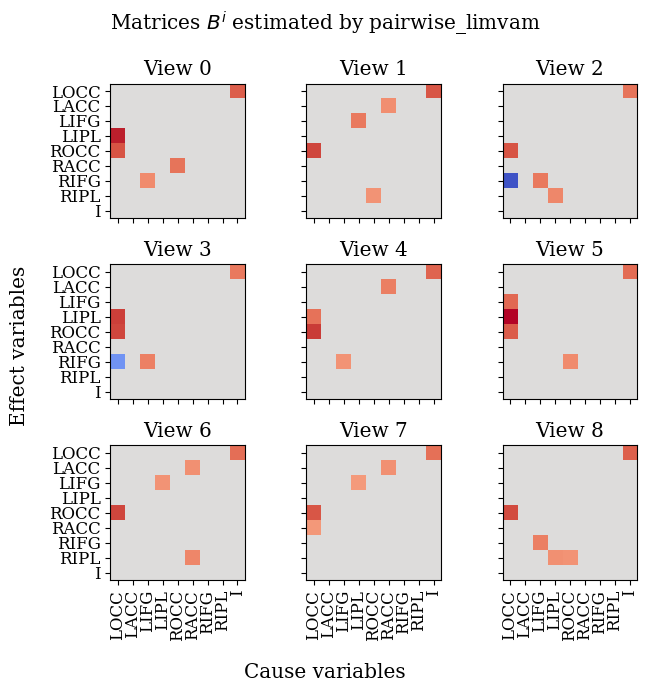

In [46]:
# plot all matrices Bi
def plot_heat_maps(B, suptitle="", n_entries=5):
    m, p, _ = B.shape
    fig, axes = plt.subplots(3, 3, figsize=(7, 7), sharex=True, sharey=True)
    norm = TwoSlopeNorm(vmin=min(-1, np.min(B)), vmax=max(1, np.max(B)), vcenter=0)
    for i in range(p):
        ax = axes[i // 3, i % 3]
        B_i_main, _ = keep_main_entries(B[i], n_entries=n_entries)
        im = ax.imshow(B_i_main, norm=norm, cmap="coolwarm")
        ax.set_title(f"View {i}")
        ax.set_xticks(np.arange(p))
        ax.set_xticklabels(cols, rotation=90)
        ax.set_yticks(np.arange(p))
        ax.set_yticklabels(cols)
    fig.supxlabel("Cause variables", y=0.02)
    fig.supylabel("Effect variables", x=0.05)
    fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()

plot_heat_maps(
    B, 
    suptitle=r"Matrices $B^i$ estimated by " + algo,
    n_entries=5,
)

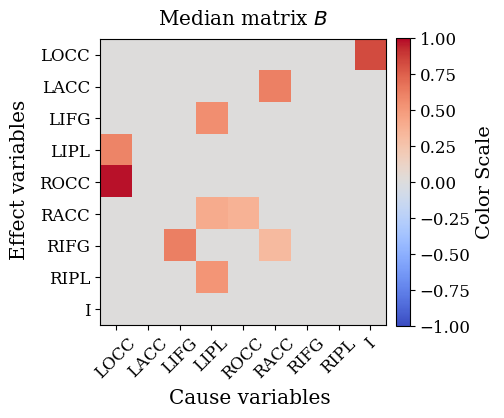

Effect 0 : LOCC -> ROCC
Effect 1 : I -> LOCC
Effect 2 : LIFG -> RIFG
Effect 3 : RACC -> LACC
Effect 4 : LOCC -> LIPL
Effect 5 : LIPL -> LIFG
Effect 6 : LIPL -> RIPL
Effect 7 : LIPL -> RACC
Effect 8 : ROCC -> RACC
Effect 9 : RACC -> RIFG


In [47]:
# plot median matrix
B_median = np.median(B, axis=0)

if keep_n_entries is not None:
    B_median_masked, B_rank = keep_main_entries(B_median, keep_n_entries)

def plot_heat_map(B, save=False):
    fig, ax = plt.subplots(figsize=(4, 4))
    norm = TwoSlopeNorm(vmin=min(-1, np.min(B)), vmax=max(1, np.max(B)), vcenter=0)
    im = ax.imshow(B, norm=norm, cmap="coolwarm")
    ax.set_xticks(np.arange(X.shape[1]))
    ax.set_xticklabels(cols, rotation=45)
    ax.set_yticks(np.arange(X.shape[1]))
    ax.set_yticklabels(cols)
    ax.set_title(r"Median matrix $B$", y=1.02)
    cbar = fig.colorbar(im, ax=ax, fraction=0.0465, pad=0.03)
    cbar.set_label("Color Scale", fontsize=fontsize+2)
    fig.supxlabel("Cause variables", y=-0.07)
    fig.supylabel("Effect variables", x=-0.1)
    if save:
        plt.savefig("fmri_median_B.pdf", bbox_inches="tight")
    plt.show()

plot_heat_map(B_median_masked, save=save)

def print_top_effects(B_rank, n_entries=5):
    id_flat = np.argsort(B_rank.flatten())[:n_entries]
    for i, id in enumerate(id_flat):
        print(f"Effect {i} : {cols[id % X.shape[1]]} -> {cols[id // X.shape[1]]}")

print_top_effects(B_rank, n_entries=keep_n_entries)